# 🐕 Havlama Tespiti — Canlı Demo

Hazır (önceden eğitilmiş) bir modelle, hiç eğitim yapmadan, gerçek bir kayıttan
havlamaları bulacağız.

**Veri:** Berlin'de bir evde güvenlik kamerasının kaydettiği sesten 1 dakikalık
gerçek kesit. Köpek evde yalnız.

**3 adım:**
1. Sesi dinle
2. Modeli çalıştır → havlamaları bul
3. Grafikte incele + bulunan her havlamayı tek tek dinle

---
## 1. Sesi dinleyelim

Önce kendimiz duyalım. Kaç havlama sayıyorsunuz? Arka planda ne var?

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TFHUB_CACHE_DIR", os.path.abspath("../out/models"))

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

SR = 16000                                    # YAMNet 16 kHz mono bekler
ses, sr = sf.read("data/ornek_ses.wav", dtype="float32")

print(f"{len(ses)/sr:.0f} saniye, {sr} Hz, mono")
display(Audio(ses, rate=sr))

60 saniye, 16000 Hz, mono


---
## 2. Hazır modeli çalıştır

**YAMNet:** Google'ın AudioSet'te (2 milyondan fazla YouTube klibi, 521 ses sınıfı)
eğittiği model. İçinde `Dog`, `Bark`, `Howl`, `Whimper (dog)` gibi sınıflar
**hazır** geliyor — biz hiçbir şey eğitmiyoruz, sadece kullanıyoruz.

Model sesi **0.96 saniyelik** pencerelere bölüp her **0.48 saniyede** bir
521 sınıf için skor üretir.

In [2]:
import csv
import logging

import tensorflow as tf

# TF'in deprecation uyarılarını sustur — tensorflow_hub import'undan ÖNCE olmalı,
# çünkü uyarılar import sırasında bir kez basılıyor.
tf.get_logger().setLevel(logging.ERROR)

import tensorflow_hub as hub

yamnet = hub.load("https://tfhub.dev/google/yamnet/1")     # ilk seferde ~15 MB indirir

with open(yamnet.class_map_path().numpy().decode("utf-8"), encoding="utf-8") as f:
    sinif_adlari = [r["display_name"] for r in csv.DictReader(f)]

skorlar, embeddings, _ = yamnet(ses)
skorlar = skorlar.numpy()

HOP = 0.48                                    # kareler arası kayma (saniye)
kare_zamani = np.arange(len(skorlar)) * HOP

print(f"{len(sinif_adlari)} sınıf, {skorlar.shape[0]} kare")

521 sınıf, 124 kare


In [3]:
# Köpekle ilgili sınıfların en yükseğini "havlama skoru" olarak alıyoruz
kopek_siniflari = ["Bark", "Yip", "Howl", "Bow-wow", "Growling", "Whimper (dog)", "Dog"]
idx = [sinif_adlari.index(c) for c in kopek_siniflari]
havlama_skoru = skorlar[:, idx].max(axis=1)

# Modelin en emin olduğu anda ne "duyduğuna" bakalım
tepe = int(havlama_skoru.argmax())
print(f"En yüksek skor: {havlama_skoru[tepe]:.2f}  (t = {kare_zamani[tepe]:.1f}. saniye)\n")
print("Modelin bu andaki ilk 5 tahmini:")
for i in np.argsort(skorlar[tepe])[::-1][:5]:
    print(f"   {skorlar[tepe, i]:.2f}  {sinif_adlari[i]}")

En yüksek skor: 0.99  (t = 45.6. saniye)

Modelin bu andaki ilk 5 tahmini:
   1.00  Animal
   1.00  Domestic animals, pets
   0.99  Dog
   0.85  Bark
   0.39  Bow-wow


### Skorlardan havlamalara

Model kare kare skor veriyor; biz ise "kaç havlama, ne zaman" bilgisini istiyoruz.
Skorun eşiği aştığı ardışık kareleri birleştirip **olay** haline getiriyoruz
(arası 1 saniyeden az olanlar tek havlama sayılır).

In [4]:
ESIK = 0.5
PENCERE = 0.96
BIRLESTIR = 1.0            # arası bundan azsa aynı havlama say

ustunde = havlama_skoru >= ESIK
havlamalar = []
for i, aktif in enumerate(ustunde):
    if not aktif:
        continue
    bas, bit = kare_zamani[i], kare_zamani[i] + PENCERE
    if havlamalar and bas - havlamalar[-1][1] <= BIRLESTIR:
        havlamalar[-1] = (havlamalar[-1][0], bit)      # öncekine ekle
    else:
        havlamalar.append((bas, bit))

print(f"{len(havlamalar)} havlama bulundu:\n")
for n, (bas, bit) in enumerate(havlamalar, 1):
    tepe_skor = havlama_skoru[(kare_zamani >= bas - PENCERE) & (kare_zamani <= bit)].max()
    print(f"   {n}. {bas:5.1f} – {bit:5.1f} sn   ({bit-bas:.1f} sn, skor {tepe_skor:.2f})")

5 havlama bulundu:

   1.   6.7 –   8.2 sn   (1.4 sn, skor 0.72)
   2.  11.5 –  14.9 sn   (3.4 sn, skor 0.98)
   3.  19.2 –  25.4 sn   (6.2 sn, skor 0.98)
   4.  32.6 –  35.0 sn   (2.4 sn, skor 0.98)
   5.  44.6 –  48.5 sn   (3.8 sn, skor 0.99)


---
## 3. Grafikte inceleyelim

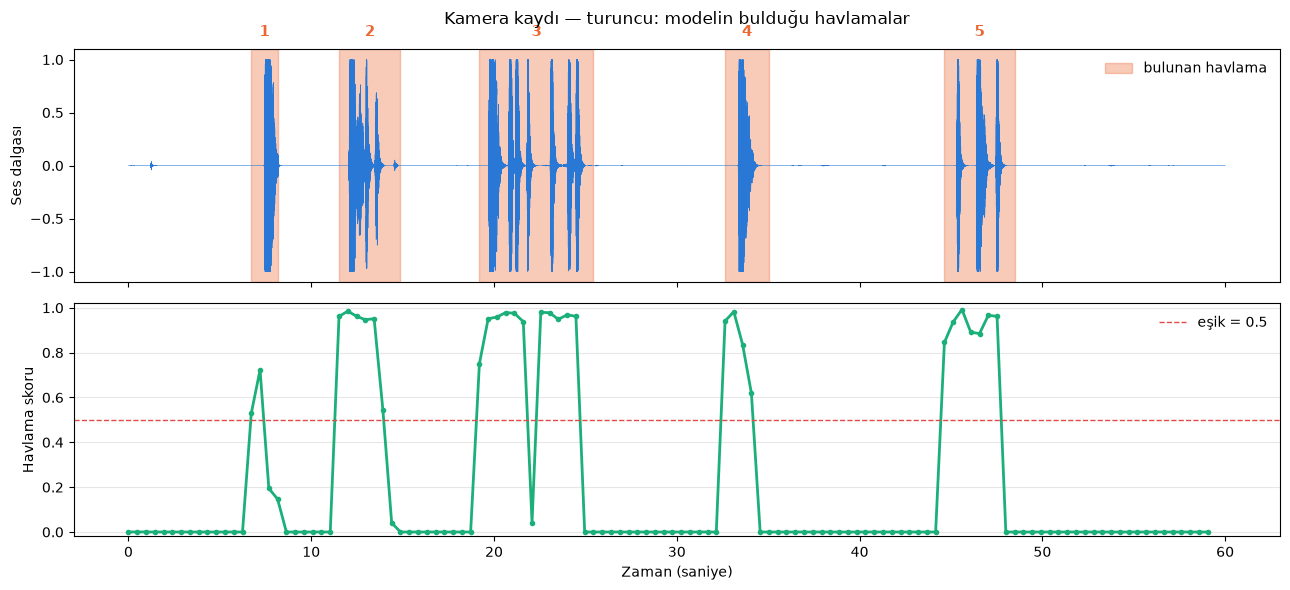

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Üst: ses dalgası + bulunan havlamalar
ax1.plot(np.arange(len(ses)) / sr, ses, color="#2a78d6", linewidth=0.4, zorder=3)
for n, (bas, bit) in enumerate(havlamalar):
    ax1.axvspan(bas, bit, color="#eb6834", alpha=0.35, zorder=1,
                label="bulunan havlama" if n == 0 else None)
    ax1.annotate(f"{n+1}", xy=((bas + bit) / 2, 1.04), xycoords=("data", "axes fraction"),
                 ha="center", va="bottom", fontsize=11, color="#eb6834",
                 weight="bold", annotation_clip=False)
ax1.set_ylabel("Ses dalgası")
ax1.set_title("Kamera kaydı — turuncu: modelin bulduğu havlamalar", pad=18)
ax1.legend(loc="upper right", frameon=False)

# Alt: modelin skoru
ax2.plot(kare_zamani, havlama_skoru, color="#1baf7a", linewidth=2, marker="o", markersize=3)
ax2.axhline(ESIK, color="#e34948", linestyle="--", linewidth=1, label=f"eşik = {ESIK}")
ax2.set_ylim(-0.02, 1.02)
ax2.set_ylabel("Havlama skoru")
ax2.set_xlabel("Zaman (saniye)")
ax2.legend(loc="upper right", frameon=False)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Şimdi bulunanları tek tek dinleyelim 🔊

Grafikteki her numaralı bandın gerçekten havlama olup olmadığını kulakla
kontrol edelim. (Her klibin başına/sonuna 1.5 saniye pay eklendi.)

In [6]:
PAY = 1.5

for n, (bas, bit) in enumerate(havlamalar, 1):
    a = max(0, int((bas - PAY) * sr))
    b = min(len(ses), int((bit + PAY) * sr))
    print(f"{n}.  {bas:.1f} – {bit:.1f} sn")
    display(Audio(ses[a:b], rate=sr))

1.  6.7 – 8.2 sn


2.  11.5 – 14.9 sn


3.  19.2 – 25.4 sn


4.  32.6 – 35.0 sn


5.  44.6 – 48.5 sn


---
## Son not

Bu kadar. Hiç eğitim yapmadık, tek satır etiketli veri kullanmadık — sadece
başkasının 2 milyon klipte öğrendiği modeli çağırdık.

Dikkat çekmeye değer iki nokta:

- **Tespitler ~1 saniye "geç" başlıyor.** Model 0.96 saniyelik pencerelere
  baktığı için havlamanın pencereye tam yerleşmesi gerekiyor.
- **Skor bazı havlamaların ortasında düşüyor** (köpek nefes alıyor). Bu yüzden
  ham skoru değil, birleştirilmiş **olayları** raporluyoruz.

Bu demonun tam üretim hali bu depoda duruyor: çoklu oturum, mutlak zaman ekseni,
elle etiketleme ile doğrulama ve raporlama dahil → `../README.md`